# Titanic Survival Prediction
**Goal:** Predict which passengers survived the Titanic disaster using structured ML workflow.

**Workflow:**
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Preprocessing
5. Model Comparison (cross-validated)
6. Hyperparameter Tuning
7. Final Evaluation & Insights

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Data Loading & Inspection

In [156]:
df = pd.read_csv('Classic Datasets/titanic.csv')


In [157]:
df.shape

(891, 12)

In [158]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [160]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [161]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [162]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


**Missing value strategy:**
- `Cabin` — 77% missing → extract deck letter, then drop
- `Age` — 20% missing → fill with median per passenger title (more accurate than global mean)
- `Embarked` — 2 rows missing → fill with mode

## 2. Exploratory Data Analysis (EDA)

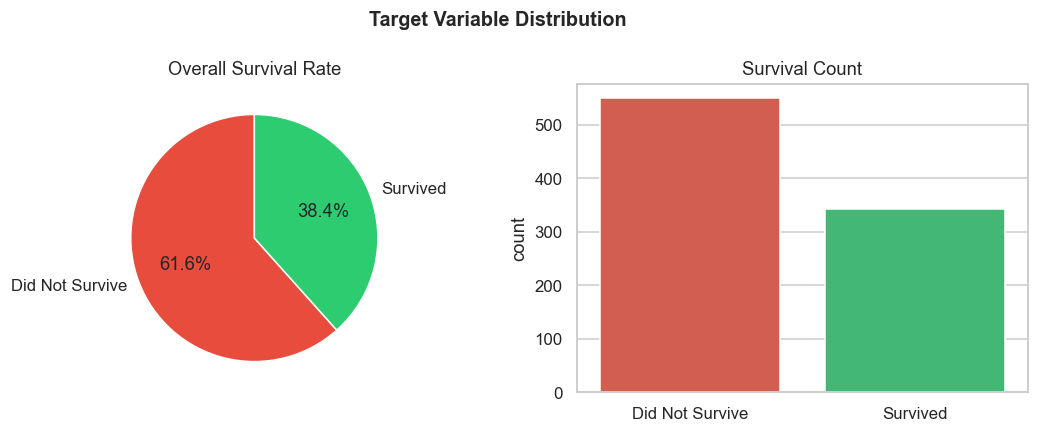

Survival rate: 38.4%


In [163]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

survival_counts = df['Survived'].value_counts()
axes[0].pie(
    survival_counts,
    labels=['Did Not Survive', 'Survived'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90
)
axes[0].set_title('Overall Survival Rate')

sns.countplot(data=df, x='Survived', palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])
axes[1].set_title('Survival Count')
axes[1].set_xlabel('')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Survival rate: {df['Survived'].mean():.1%}")

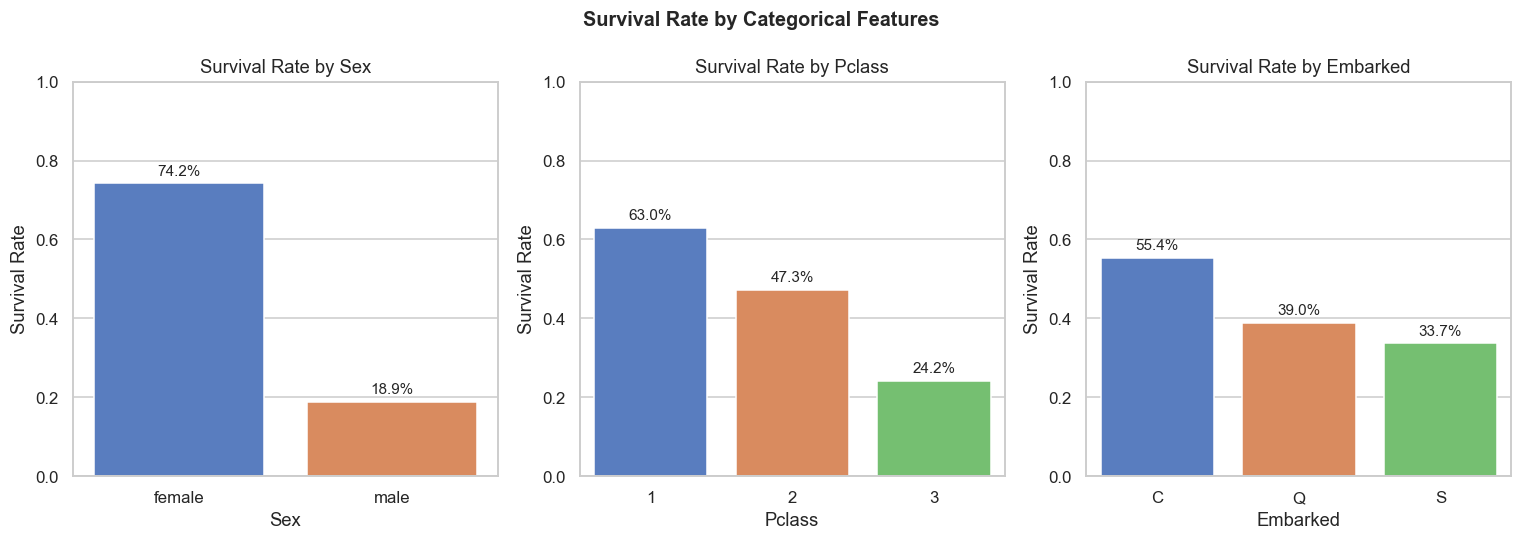

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    survival_rate = df.groupby(col)['Survived'].mean().reset_index()
    sns.barplot(data=survival_rate, x=col, y='Survived', ax=ax, palette='muted')
    ax.set_title(f'Survival Rate by {col}')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1)
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.1%}',
            ha='center', fontsize=10
        )

plt.suptitle('Survival Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

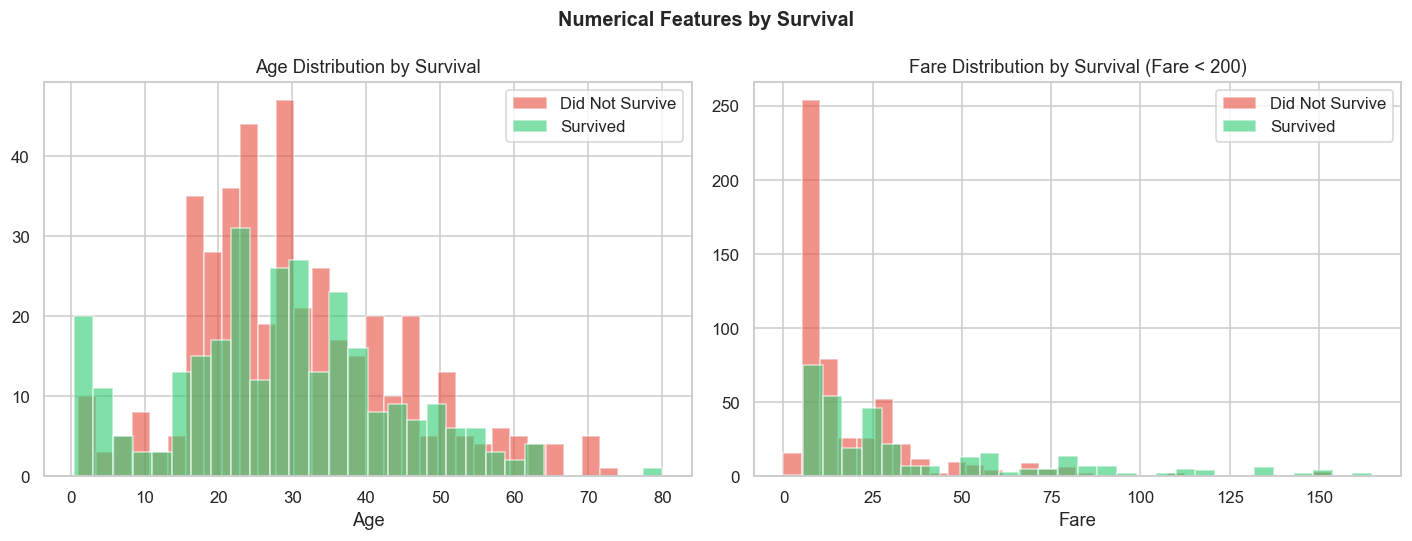

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for survived, label, color in [(0, 'Did Not Survive', '#e74c3c'), (1, 'Survived', '#2ecc71')]:
    axes[0].hist(
        df[df['Survived'] == survived]['Age'].dropna(),
        bins=30, alpha=0.6, label=label, color=color
    )
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].legend()

df_fare = df[df['Fare'] < 200]
for survived, label, color in [(0, 'Did Not Survive', '#e74c3c'), (1, 'Survived', '#2ecc71')]:
    axes[1].hist(
        df_fare[df_fare['Survived'] == survived]['Fare'],
        bins=30, alpha=0.6, label=label, color=color
    )
axes[1].set_title('Fare Distribution by Survival (Fare < 200)')
axes[1].set_xlabel('Fare')
axes[1].legend()

plt.suptitle('Numerical Features by Survival', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

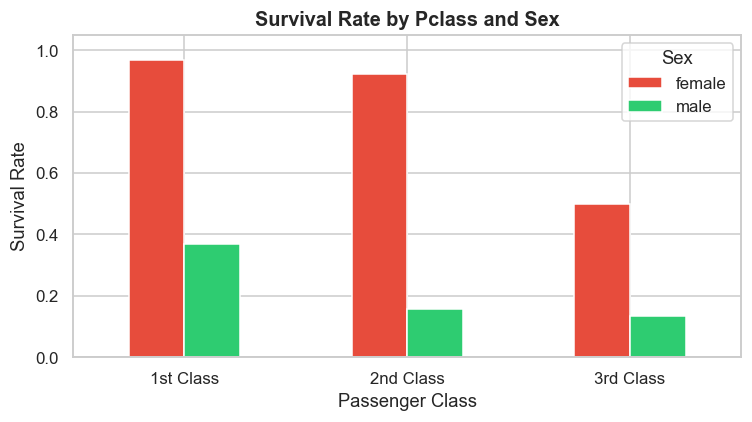

Key finding: Women in 1st class had near-100% survival; men in 3rd class had <15% survival.


In [166]:
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
pivot.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Survival Rate by Pclass and Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1.05)
ax.legend(title='Sex')
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
plt.tight_layout()
plt.show()

print("Key finding: Women in 1st class had near-100% survival; men in 3rd class had <15% survival.")

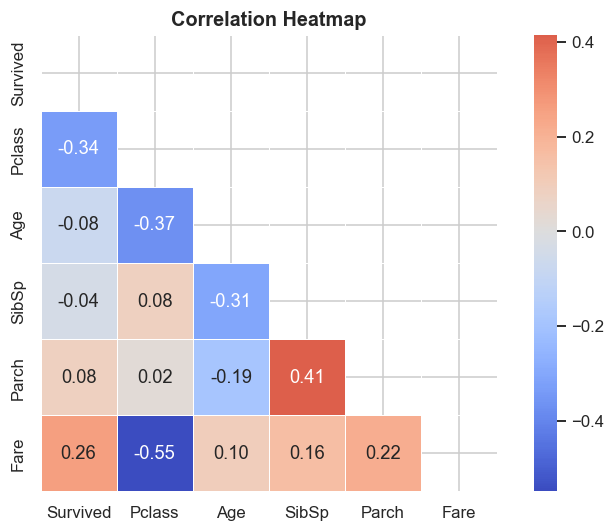

In [167]:
df_num = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Good features are the difference between a good model and a great one. We extract signal that raw columns don't expose directly.

In [168]:
df_fe = df.copy()

# --- Title from Name ---
# Titles carry strong social status + age signal (Master = young boy)
df_fe['Title'] = df_fe['Name'].str.extract(r',\s*([^.]+)\.')
rare_titles = df_fe['Title'].value_counts()[df_fe['Title'].value_counts() < 10].index
df_fe['Title'] = df_fe['Title'].replace(rare_titles, 'Rare')
df_fe['Title'] = df_fe['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
print('Title distribution:')
print(df_fe['Title'].value_counts())

# --- Survival rate per title (validation) ---
print('\nSurvival rate per title:')
print(df_fe.groupby('Title')['Survived'].mean().round(2))

Title distribution:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Survival rate per title:
Title
Master    0.57
Miss      0.70
Mr        0.16
Mrs       0.79
Rare      0.44
Name: Survived, dtype: float64


In [169]:
# --- Fill Age by median within Title group ---
title_age_medians = df_fe.groupby('Title')['Age'].transform('median')
df_fe['Age'] = df_fe['Age'].fillna(title_age_medians)

# --- Family size features ---
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1
df_fe['IsAlone'] = (df_fe['FamilySize'] == 1).astype(int)

# --- Fare per person (shared tickets inflate Fare) ---
df_fe['FarePerPerson'] = df_fe['Fare'] / df_fe['FamilySize']

# --- Age and Fare bins ---
df_fe['AgeBand'] = pd.cut(df_fe['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4])
df_fe['FareBand'] = pd.qcut(df_fe['Fare'], q=4, labels=[0, 1, 2, 3])

# --- Deck from Cabin ---
df_fe['Deck'] = df_fe['Cabin'].str[0].fillna('Unknown')

# --- Fix Embarked missing (only 2 rows) ---
df_fe['Embarked'] = df_fe['Embarked'].fillna(df_fe['Embarked'].mode()[0])

print('New features created: Title, FamilySize, IsAlone, FarePerPerson, AgeBand, FareBand, Deck')
df_fe[['FamilySize', 'IsAlone', 'FarePerPerson', 'AgeBand', 'FareBand', 'Deck', 'Title']].head()

New features created: Title, FamilySize, IsAlone, FarePerPerson, AgeBand, FareBand, Deck


,FamilySize,IsAlone,FarePerPerson,AgeBand,FareBand,Deck,Title
0,2,0,3.62500,2,0,Unknown,Mr
1,2,0,35.64165,3,3,C,Mrs
2,1,1,7.92500,2,1,Unknown,Miss
3,2,0,26.55000,2,3,C,Mrs
4,1,1,8.05000,2,1,Unknown,Mr


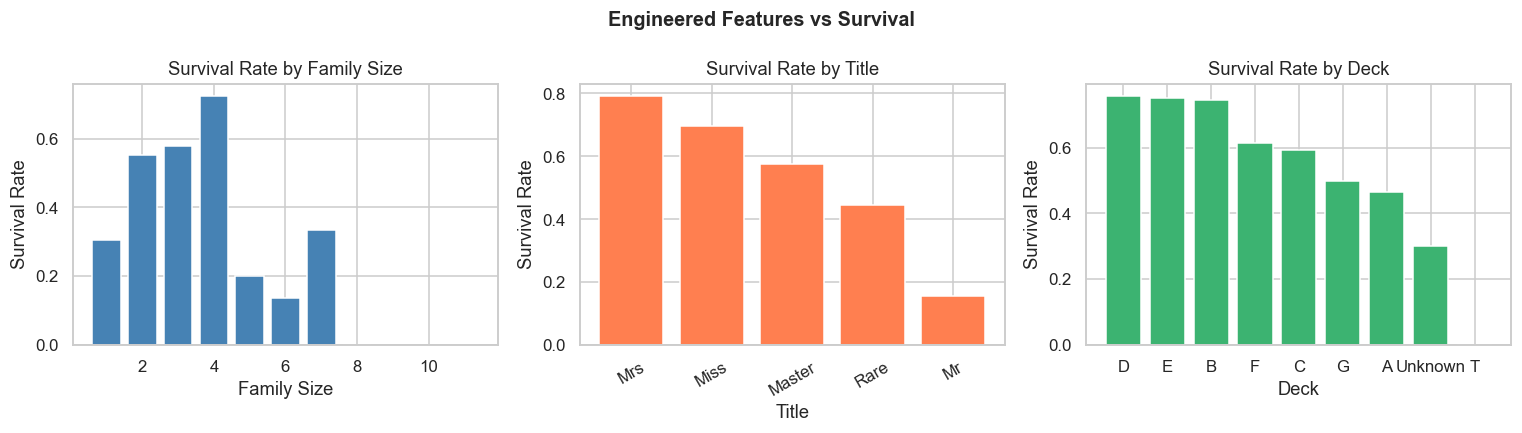

In [170]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Family size vs survival
family_surv = df_fe.groupby('FamilySize')['Survived'].mean()
axes[0].bar(family_surv.index, family_surv.values, color='steelblue', edgecolor='white')
axes[0].set_title('Survival Rate by Family Size')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate')

# Title vs survival
title_surv = df_fe.groupby('Title')['Survived'].mean().sort_values(ascending=False)
axes[1].bar(title_surv.index, title_surv.values, color='coral', edgecolor='white')
axes[1].set_title('Survival Rate by Title')
axes[1].set_xlabel('Title')
axes[1].set_ylabel('Survival Rate')
axes[1].tick_params(axis='x', rotation=30)

# Deck vs survival
deck_surv = df_fe.groupby('Deck')['Survived'].mean().sort_values(ascending=False)
axes[2].bar(deck_surv.index, deck_surv.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Survival Rate by Deck')
axes[2].set_xlabel('Deck')
axes[2].set_ylabel('Survival Rate')

plt.suptitle('Engineered Features vs Survival', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing

Encode all categorical columns and assemble the final feature matrix.

In [171]:
df_model = df_fe.copy()

# Drop columns we won't use
df_model.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare', 'Age', 'SibSp', 'Parch'], inplace=True)

# Encode binary
df_model['Sex'] = df_model['Sex'].map({'male': 1, 'female': 0})

# One-hot encode multi-category
df_model = pd.get_dummies(df_model, columns=['Embarked', 'Title', 'Deck'], drop_first=False)

# Cast ordinal bands to int
df_model['AgeBand'] = df_model['AgeBand'].astype(int)
df_model['FareBand'] = df_model['FareBand'].astype(int)

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {list(X.columns)}')

Feature matrix shape: (891, 24)
Features: ['Pclass', 'Sex', 'FamilySize', 'IsAlone', 'FarePerPerson', 'AgeBand', 'FareBand', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


In [172]:
# Stratified split preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train survival rate: {y_train.mean():.1%} | Test survival rate: {y_test.mean():.1%}')

Train: (712, 24), Test: (179, 24)
Train survival rate: 38.3% | Test survival rate: 38.5%


## 5. Model Comparison

We evaluate 7 models using **5-fold stratified cross-validation** on the training set — all on the same data split, so comparison is fair. Metrics: Accuracy, F1, ROC-AUC.

In [173]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1)
}

results = []
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()
    roc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': roc})
    print(f'{name:25s}  Acc={acc:.3f}  F1={f1:.3f}  AUC={roc:.3f}')

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print('\nRanked by ROC-AUC:')
results_df.round(3)

Logistic Regression        Acc=0.819  F1=0.760  AUC=0.869
KNN                        Acc=0.809  F1=0.741  AUC=0.830
Decision Tree              Acc=0.806  F1=0.741  AUC=0.790
Random Forest              Acc=0.805  F1=0.741  AUC=0.862
Gradient Boosting          Acc=0.829  F1=0.773  AUC=0.886
XGBoost                    Acc=0.819  F1=0.757  AUC=0.873
LightGBM                   Acc=0.826  F1=0.764  AUC=0.872

Ranked by ROC-AUC:


,Accuracy,F1,ROC-AUC
Model,,,
Gradient Boosting,0.829,0.773,0.886
XGBoost,0.819,0.757,0.873
LightGBM,0.826,0.764,0.872
Logistic Regression,0.819,0.760,0.869
Random Forest,0.805,0.741,0.862
KNN,0.809,0.741,0.830
Decision Tree,0.806,0.741,0.790


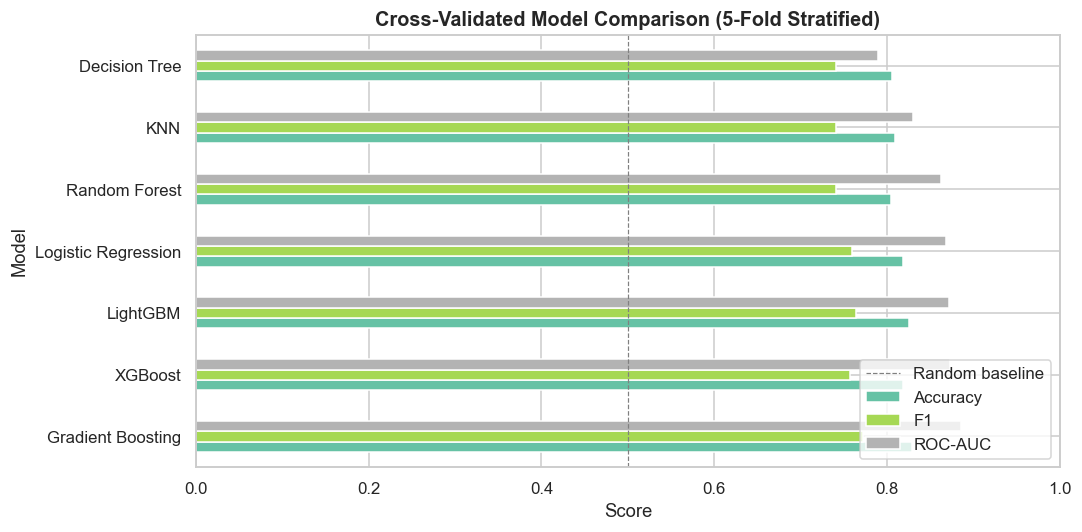

In [174]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='barh', ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlim(0, 1)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_title('Cross-Validated Model Comparison (5-Fold Stratified)', fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

We tune the best-performing model (XGBoost) using `GridSearchCV` with stratified CV.

In [175]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'Best ROC-AUC (CV): {grid_search.best_score_:.4f}')
print(f'Best params: {grid_search.best_params_}')

Best ROC-AUC (CV): 0.8946
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}


## 7. Final Evaluation on Hold-Out Test Set

We evaluate the tuned model once on the test set — only now, to avoid data leakage.

In [176]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print('=== Final Test Set Evaluation (Tuned XGBoost) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

=== Final Test Set Evaluation (Tuned XGBoost) ===
Accuracy : 0.8101
F1 Score : 0.7424
ROC-AUC  : 0.8495

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



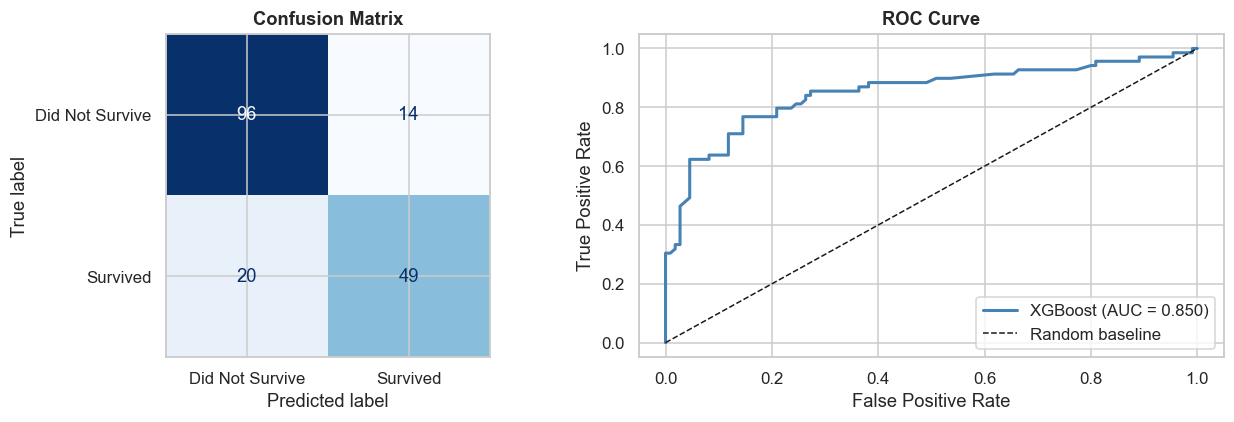

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

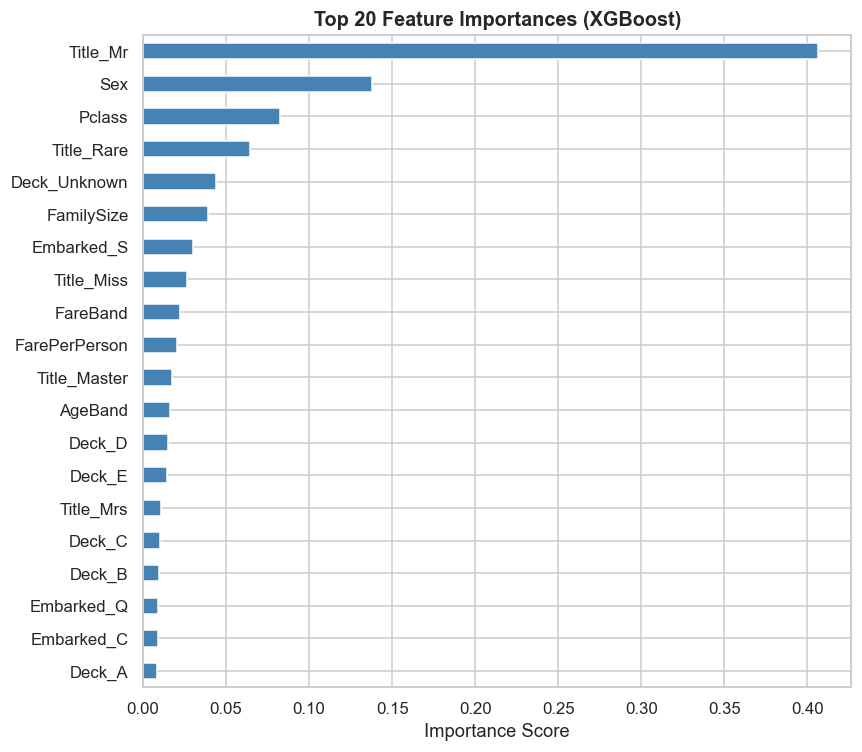

Top 10 most important features:
Title_Mr         0.406287
Sex              0.137616
Pclass           0.082352
Title_Rare       0.064666
Deck_Unknown     0.044240
FamilySize       0.038914
Embarked_S       0.029974
Title_Miss       0.026722
FareBand         0.022030
FarePerPerson    0.020578
dtype: float32


In [178]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(feat_imp.sort_values(ascending=False).head(10))

## 8. Key Findings & Conclusions

### What drives survival?
1. **Sex** — Strongest predictor. Women survived at ~74% vs men at ~19% ("women and children first" policy).
2. **Pclass** — 1st class passengers had 3× the survival rate of 3rd class.
3. **Title** — Extracts social status + age signal beyond Sex alone. `Master` (boys) had high survival.
4. **Fare / FarePerPerson** — Proxy for wealth and deck location.
5. **FamilySize** — Small families (2–4) survived better than solo travelers or large groups.

### Model performance (final test set — Tuned XGBoost)

Accuracy : 0.8101
F1 Score : 0.7424
ROC-AUC  : 0.8495